In [1]:
import sys
sys.path.append('/home/carroll/Documents/')

import numpy as np
import os
import pandas as pd
from glob import glob

import matplotlib.pyplot as plt
import scipy.io as scio
from scipy.signal import savgol_filter
import asdprocessor
import asd_jump_correction

os.chdir('/home/carroll/Documents/')

# %matplotlib widget

In [ ]:
# prep in situ spectra for use as calibration targets

In [86]:
wl_neon = np.loadtxt('/store/carroll/col/data/wavelengths_neon.txt')[:,1]*1000
wl_neon_nan = np.loadtxt('/store/carroll/col/data/wl_nan.txt')
fwhm_neon = np.loadtxt('/store/carroll/col/data/wavelengths_neon.txt')[:,-1]*1000

wl_asd = np.loadtxt('/store/carroll/col/data/wavelengths_asd.txt')[:,0]

def closest_wl(mv, wl):
    return np.argmin(np.abs(wl-mv))
wl_asd_nan = np.copy(wl_asd)
wl_asd_nan[closest_wl(1360, wl_asd):closest_wl(1410, wl_asd)] = np.nan
wl_asd_nan[closest_wl(1800, wl_asd):closest_wl(1970, wl_asd)] = np.nan

In [56]:
# 2025
# snodgrass 7/10

df = pd.read_csv('/store/carroll/col/data/2025/insitu/target_rfl_20250723.csv')
df = df[df['file_tag'].isin(['20250710_busstop_prx', '20250710_busstop_cp'])]
rfl_cols = [x for x in df.columns if x not in ['file_tag', 'date', 'site']]
wl = [float(x) for x in df.columns if x not in ['file_tag', 'date', 'site']]

# get mean
mean = df.drop(columns=['date', 'file_tag']).groupby('site').mean()
mean.columns = wl # column headers to float

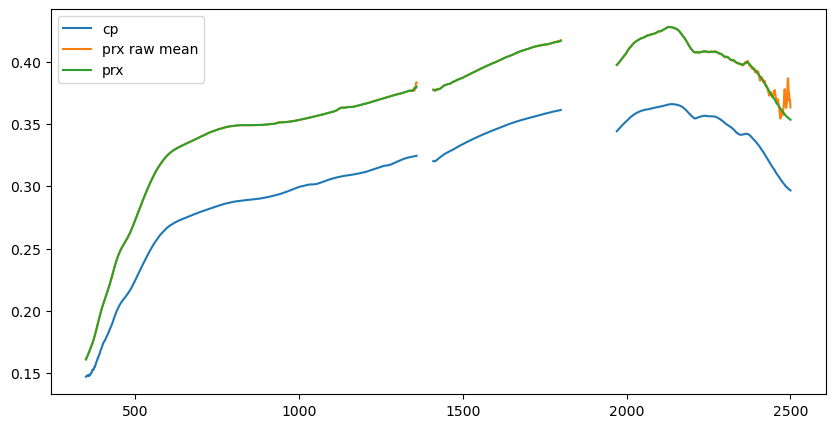

In [57]:
# snoddgrass bus stop 7/10

og = mean.loc['snodgrass_bus_stop'].copy()

# smooth
smoothed = savgol_filter(mean.loc['snodgrass_bus_stop'], window_length=25, polyorder=2)
mean.loc[mean.index=='snodgrass_bus_stop', :] = smoothed

# tamp down end
dif = mean.loc['snodgrass_bus_stop',2375] - mean.loc['snodgrass_bus_stop_cp',2375]
for i in range(2375, 2501, 1):
    mean.loc['snodgrass_bus_stop',i] = mean.loc['snodgrass_bus_stop_cp',i] + dif

# bring up 1800
dif = mean.loc['snodgrass_bus_stop',1776] - mean.loc['snodgrass_bus_stop_cp',1776] # dif at local max
for i in range(1776, 1805, 1):
    mean.loc['snodgrass_bus_stop',i] = mean.loc['snodgrass_bus_stop_cp',i] + dif
    
fig = plt.figure(figsize=(10,5))

plt.plot(wl_asd_nan, mean.loc['snodgrass_bus_stop_cp'], label='cp')
plt.plot(wl_asd_nan, og, label='prx raw mean')
plt.plot(wl_asd_nan, mean.loc['snodgrass_bus_stop'], label='prx')

plt.legend()
plt.show()

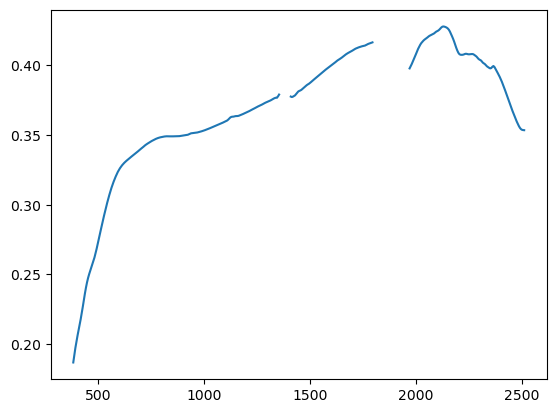

In [93]:
# summarize to neon wvl
rfl_asd = mean.loc['snodgrass_bus_stop']
rfl_neon = np.zeros_like(wl_neon)
for i, (center, fwhm) in enumerate(zip(wl_neon, fwhm_neon)):
    sigma = fwhm / (2*np.sqrt(2*np.log(2)))  # Convert FWHM → Gaussian σ
    weights = np.exp(-0.5 * ((wl_asd - center) / sigma)**2)
    weights /= np.sum(weights)               # Normalize weights
    rfl_neon[i] = np.sum(rfl_asd * weights)     # Weighted average
rfl_neon = np.stack([wl_neon, rfl_neon], axis=1)

fig = plt.figure()
plt.plot(wl_nan, rfl_neon[:,1])
plt.show()

In [ ]:
# export
np.savetxt('/store/carroll/col/data/2025/insitu/cal_snodgrass_bus_stop_neon.txt', rfl_neon)